In [24]:
import pandas as pd
import numpy as np


df = pd.read_csv('../dataset/telco_churn_clean.csv')
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [2]:
#vamos eliminar la columna customerID ya que no es relevante para el modelo
df.drop('customerID', axis=1)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [25]:
#vamos a convertir los datos de la columna 'Churn' en modelo binario, 
# donde 1 significa que el cliente se ha ido y 0 significa que el cliente se ha quedado
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})


In [26]:
columnas_categoricas = df.select_dtypes(include='object').columns.tolist()
print(columnas_categoricas)

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


C:\Users\rafae\AppData\Local\Temp\ipykernel_37708\2229964157.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = df.select_dtypes(include='object').columns.tolist()


In [29]:
df_encoded = pd.get_dummies(df, columns=columnas_categoricas, drop_first=True)
df_encoded.head()
df_encoded.isnull().sum().sum()
df_encoded.isnull().sum()[df_encoded.isnull().sum() > 0]
df_encoded = df_encoded.dropna()

In [30]:
df_encoded.shape

(7032, 7073)

Vamos con el Paso 2: Dividir los datos en entrenamiento y prueba.

In [31]:
#vamos seperar las variables independientes de la variable dependiente
# osea la varible que queremos predecir, en este caso es la columna 'Churn'
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

In [32]:
from sklearn.model_selection import train_test_split

test_size=0.2 → usamos 80% de los datos para entrenar y 20% para probar.
random_state=42 → fija una "semilla" aleatoria, para que si vuelves a correr el código, obtengas exactamente la misma división (reproducibilidad).
stratify=y → esto es importante en tu caso: asegura que la proporción de 73.5%/26.5% (No/Sí cancelación) se mantenga igual tanto en el grupo de entrenamiento como en el de prueba. Sin esto, podrías terminar con una división desbalanceada por casualidad.

In [33]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Entrenamiento:", X_train.shape)
print("Prueba:", X_test.shape)

Entrenamiento: (5625, 7072)
Prueba: (1407, 7072)


In [38]:
#vereficamos la proporcion de churn se mantuvo para el conjunto de entrenamiento y prueba
print(y_train.value_counts(normalize=True))
print(y_test.value_counts(normalize=True))

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Churn
0    0.734222
1    0.265778
Name: proportion, dtype: float64
Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64


Entrenar el modelo (Regresión Logística)

In [39]:
from sklearn.linear_model import LogisticRegression

In [40]:
#vamos a crear el modelo de regresion logistica
model_lr = LogisticRegression(max_iter=1000, random_state=42)
model_lr.fit(X_train_scaled, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

max_iter=1000 → le da al modelo más "intentos" para encontrar la mejor solución matemática internamente 
(a veces con el valor por defecto no le alcanza y da una advertencia).
random_state=42 → misma idea que antes, para que los resultados sean reproducibles.

In [41]:
y_pred = model_lr.predict(X_test_scaled)

In [42]:
#revisamos las predicciones y los valores reales
print("Predicciones:", y_pred[:10])
print("Valores reales:", y_test[:10].values)

Predicciones: [0 0 0 0 0 0 0 0 0 0]
Valores reales: [0 0 0 1 0 1 0 0 1 0]


#Evaluacion del modelo

In [43]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, confusion_matrix, classification_report
)

In [44]:
#calculamos el accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f"Accuracy: {accuracy:.2%}")

Accuracy: 77.97%


In [45]:
#calculamos precision, recall
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
print(f"Precision: {precision:.2%}")
print(f"Recall: {recall:.2%}")

Precision: 69.75%
Recall: 30.21%


In [47]:
#calculamos el f1 score
f1 = f1_score(y_test, y_pred)
print(f"F1-score: {f1:.2%}")

F1-score: 42.16%


In [48]:
#matriz de confusion
cm = confusion_matrix(y_test, y_pred)
print("Matriz de Confusión:")
print(cm)

Matriz de Confusión:
[[984  49]
 [261 113]]


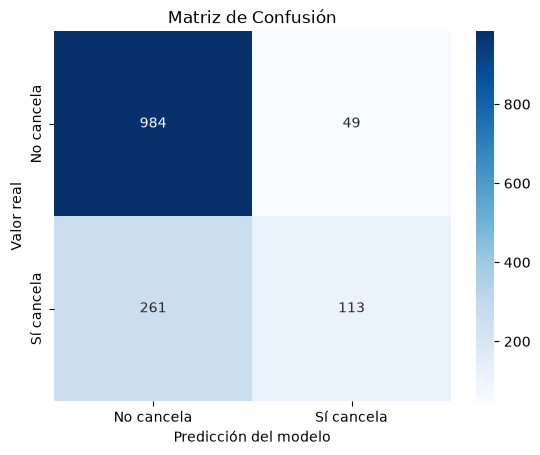

In [49]:
#vamos a visualizar la matriz de confusion con un mapa de calor
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['No cancela', 'Sí cancela'],
            yticklabels=['No cancela', 'Sí cancela'])
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión')
plt.show()

In [50]:
#generamos un reporte de clasificacion
print(classification_report(y_test, y_pred, target_names=['No cancela', 'Sí cancela']))

              precision    recall  f1-score   support

  No cancela       0.79      0.95      0.86      1033
  Sí cancela       0.70      0.30      0.42       374

    accuracy                           0.78      1407
   macro avg       0.74      0.63      0.64      1407
weighted avg       0.77      0.78      0.75      1407



In [52]:
#procedemos a entrenar un modelo de Random Forest para comparar los resultados con el modelo de regresion logistica
from sklearn.ensemble import RandomForestClassifier

In [54]:
modelo_rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    class_weight='balanced',
    random_state=42
)

modelo_rf.fit(X_train_scaled, y_train)
y_pred_rf = modelo_rf.predict(X_test_scaled)

In [56]:
#vamos a evaluar las metricas
print(classification_report(y_test, y_pred_rf, target_names=['No cancela', 'Sí cancela']))

              precision    recall  f1-score   support

  No cancela       0.91      0.67      0.77      1033
  Sí cancela       0.47      0.81      0.59       374

    accuracy                           0.70      1407
   macro avg       0.69      0.74      0.68      1407
weighted avg       0.79      0.70      0.72      1407



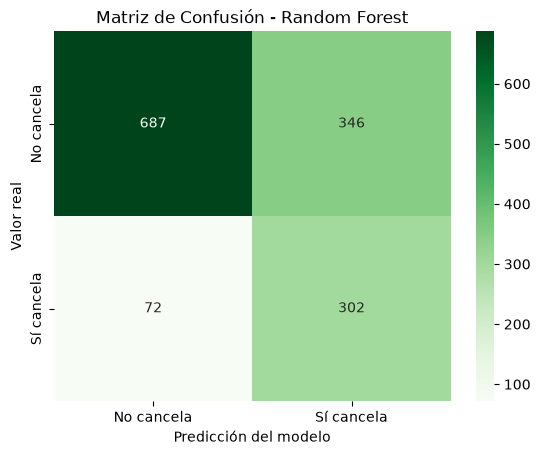

In [57]:
#revisamos la nueva matriz de confusion
cm_rf = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm_rf, annot=True, fmt='d', cmap='Greens',
            xticklabels=['No cancela', 'Sí cancela'],
            yticklabels=['No cancela', 'Sí cancela'])
plt.xlabel('Predicción del modelo')
plt.ylabel('Valor real')
plt.title('Matriz de Confusión - Random Forest')
plt.show()

In [58]:
#ahora comparemos ambos modelos en un solo reporte de clasificacion
comparacion = pd.DataFrame({
    'Métrica': ['Accuracy', 'Precision', 'Recall', 'F1-score'],
    'Regresión Logística': [
        accuracy_score(y_test, y_pred),
        precision_score(y_test, y_pred),
        recall_score(y_test, y_pred),
        f1_score(y_test, y_pred)
    ],
    'Random Forest': [
        accuracy_score(y_test, y_pred_rf),
        precision_score(y_test, y_pred_rf),
        recall_score(y_test, y_pred_rf),
        f1_score(y_test, y_pred_rf)
    ]
})
print(comparacion)

     Métrica  Regresión Logística  Random Forest
0   Accuracy             0.779673       0.702914
1  Precision             0.697531       0.466049
2     Recall             0.302139       0.807487
3   F1-score             0.421642       0.590998


In [61]:
#luego de la comparacion procedemos a guardar el modelo de Random Forest ya que es el que tiene mejor desempeño
import joblib
import os

joblib.dump(modelo_rf, '../model/model.pkl')
joblib.dump(scaler, '../model/scaler.pkl')

['../model/scaler.pkl']

In [62]:
#guardamos las columnas del dataset para poder usarlas en el modelo de prediccion
import json

columnas = X.columns.tolist()
with open('../model/columnas.json', 'w') as f:
    json.dump(columnas, f)


